In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

from algs.cd_poly import *

In [30]:
IMAGE_SIZE = 28 * 28  # MNIST image dimensions
LATENT_DIM = 10      # Dimension of the latent space
BATCH_SIZE = 256
LEARNING_RATE = 4e-3
NUM_EPOCHS = 50
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")

In [39]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

def dl_from_digit(ds, digit: int):
    indices = []
    for i, (image, label) in enumerate(ds):
        if label == digit:
            indices.append(i)
    digit_ds = Subset(ds, indices)
    return DataLoader(digit_ds, batch_size=BATCH_SIZE, shuffle=True)

In [47]:
class AutoencoderCNN(nn.Module):
    def __init__(self, input_channels=1, latent_dim=10):
        super(AutoencoderCNN, self).__init__()

        # Encoder
        # Input: [batch_size, 1, 28, 28]
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, stride=1, padding=1), # Output: [batch_size, 16, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # [..., 16, 14, 14]

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Output: [batch_size, 32, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # [..., 32, 7, 7]

            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim)
        )

        # Decoder
        # Input: [batch_size, latent_dim]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7), # Reshape back to convolutional dimensions
            nn.Unflatten(1, (32, 7, 7)),

            nn.ConvTranspose2d(32, 32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),

            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1), #
            nn.Sigmoid(),

        )

    def forward(self, x):
        # Ensure input is reshaped for CNN: [batch_size, channels, height, width]
        # MNIST images are typically 28x28, 1 channel

        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec, enc

In [67]:
model = AutoencoderCNN(input_channels=1, latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss() # Mean Squared Error for reconstruction
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

sum(p.numel() for p in model.parameters() if p.requires_grad)

51755

In [58]:
def train(optimizer, dl, n_epochs=5):
    losses = []
    for epoch in range(n_epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(dl):
            # Flatten the images and move to device
            data = data.to(DEVICE)

            # Forward pass
            rec, enc = model(data)
            loss = criterion(rec, data)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * data.size(0)

        avg_loss = total_loss / len(train_dl.dataset)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")

    print("Training finished.")
    plt.plot(losses)
    plt.yscale('log')

In [64]:
def train_on_digit(digit: int, n_epochs=5):
    dl = dl_from_digit(train_ds, digit=digit)
    model = AutoencoderCNN(1, 10)
    opt = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train(opt, dl, n_epochs=n_epochs)
    return model

Epoch [1/10], Loss: 0.0357
Epoch [2/10], Loss: 0.0195
Epoch [3/10], Loss: 0.0178
Epoch [4/10], Loss: 0.0169
Epoch [5/10], Loss: 0.0163
Epoch [6/10], Loss: 0.0158
Epoch [7/10], Loss: 0.0155
Epoch [8/10], Loss: 0.0153
Epoch [9/10], Loss: 0.0151
Epoch [10/10], Loss: 0.0149
Training finished.


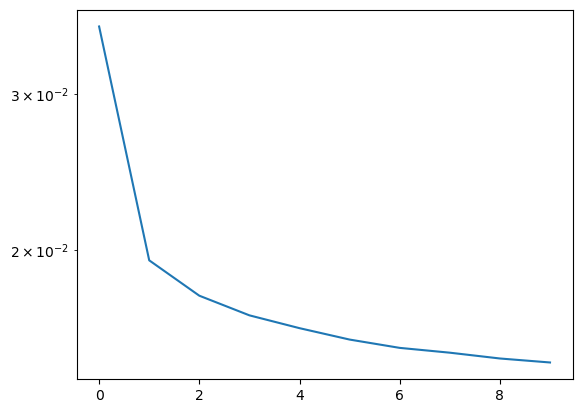

In [68]:
train(optimizer, train_dl, n_epochs=10)

In [70]:
save_path = 'models/mnist.pth'
if not os.path.exists(save_path):
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to '{save_path}'")
else:
    print(f"Model already exists at '{save_path}'; not overwriting.")

Model saved to 'models/mnist.pth'


In [8]:
# load if needed
model = AutoencoderCNN(latent_dim=10).to(DEVICE)
model.load_state_dict(torch.load('mnist.pth'))

<All keys matched successfully>

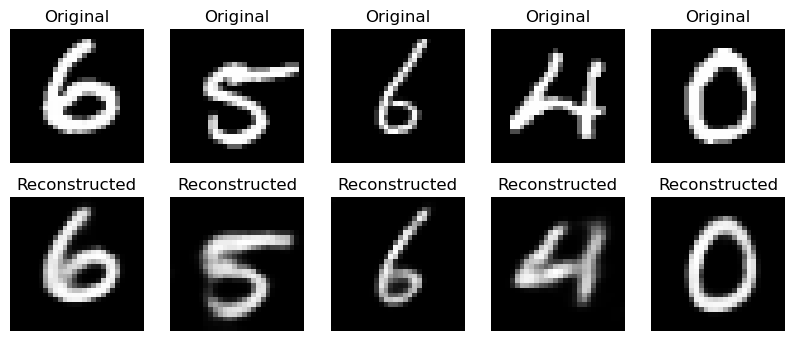

In [81]:
model.eval()
with torch.no_grad():
    sample_data, _ = next(iter(train_dl))
    sample_data = sample_data.to(DEVICE)
    rec, _ = model(sample_data)
    rec = rec.cpu()
    original_samples = sample_data.cpu()

    plt.figure(figsize=(10, 4))
    for i in range(5):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(original_samples[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        ax = plt.subplot(2, 5, i + 6)
        plt.imshow(rec[i].squeeze(), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

Outlier detection methods:
- one-class SVM
- look at reconstruction error of AE
- some kind of contrastive learning based on synthetic failure data
- clustering + distance

In [99]:
latents_tr = []

for i in range(10):
    dl = dl_from_digit(train_ds, i)
    latents_i = []
    for X, _ in dl:
        X = X.to(DEVICE)
        with torch.no_grad():
            _, enc = model(X)
        latents_i.append(enc.detach().to('cpu').numpy())
    latents_i = np.concatenate(latents_i)
    latents_tr.append(latents_i)

In [102]:
latents_te = []

for i in range(10):
    dl = dl_from_digit(test_ds, i)
    latents_i = []
    for X, _ in dl:
        X = X.to(DEVICE)
        with torch.no_grad():
            _, enc = model(X)
        latents_i.append(enc.detach().to('cpu').numpy())
    latents_i = np.concatenate(latents_i)
    latents_te.append(latents_i)

In [110]:
import seaborn as sns

In [121]:
correct = np.zeros((10, 10))
for i in range(10):
    p = CDPolynomial(latents_tr[i], degree=4)
    for j in range(10):
        correct[i, j] = (p(latents_te[j]) > p.mean).mean()

In [122]:
correct

array([[0.37142857, 1.        , 1.        , 1.        , 1.        ,
        0.99887892, 0.99895616, 1.        , 1.        , 1.        ],
       [1.        , 0.24757709, 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 0.40697674, 0.9960396 , 1.        ,
        1.        , 1.        , 0.99902724, 0.99897331, 1.        ],
       [1.        , 1.        , 1.        , 0.36534653, 1.        ,
        0.98654709, 1.        , 1.        , 0.98562628, 0.9950446 ],
       [1.        , 1.        , 1.        , 1.        , 0.37169043,
        1.        , 0.99895616, 1.        , 1.        , 0.88899901],
       [1.        , 1.        , 1.        , 0.98217822, 1.        ,
        0.38452915, 0.99895616, 1.        , 0.98049281, 0.9950446 ],
       [1.        , 1.        , 1.        , 1.        , 0.99898167,
        0.99887892, 0.38622129, 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.       

Text(50.722222222222214, 0.5, 'Train Digit')

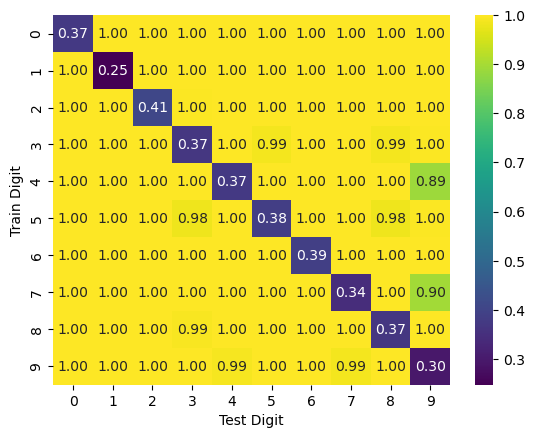

In [123]:
sns.heatmap(correct, annot=True, fmt=".2f", cmap="viridis", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Test Digit")
plt.ylabel("Train Digit")